<a href="https://colab.research.google.com/github/erichilarysmithsr/CULAPSEDatapplace/blob/main/BIOS399_SchillerWoods_Research_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Research Question**: How does river chemistry influence wildlife foraging at forest edges?

**Mentors**: Brown (Bio), Ferguson (Chem), Miranda (Math).

**Schedule**: Mondays (Field), Thursdays (Lab/Data).

In [ ]:
# Standard data tools
import pandas as pd
import numpy as np

# Mapping and Viz tools
import folium
import matplotlib.pyplot as plt
import seaborn as sns

# Stats tools (for the end of the semester)
from scipy import stats

print("Setup Complete: Your digital lab is ready!")

Setup Complete: Your digital lab is ready!


**Interactive Site Map of Robinson Homestead**

In [ ]:
import pandas as pd
import numpy as np
import folium

# 1. DEFINE SITE GEOMETRY (Pace 303 Bus Stop Area)
site_center = [41.9681, -87.8540]
SOURCE_DB = 123.5 # Noise level of a passing Pace Bus/Truck

# Landmark Dictionary: Coordinates and Distance to River Rd (meters)
landmarks = {
    "T00: Pace 303 Bus Stop": {"coords": [41.96825, -87.85401], "dist_road": 3.0},
    "T01: Entrance Clearing": {"coords": [41.96810, -87.85415], "dist_road": 15.0},
    "T02: Wooded Edge":       {"coords": [41.96800, -87.85435], "dist_road": 42.0},
    "T03: Inner Picnic Table":{"coords": [41.96785, -87.85420], "dist_road": 28.0}
}

# 2. PHYSICS FUNCTION: Inverse Square Law for Acoustic Masking
def get_acoustic_penalty(d):
    # L = L0 - 20 * log10(d)
    db = SOURCE_DB - (20 * np.log10(max(d, 1)))
    # Penalty (pi) scales risk perception based on noise masking hearing
    pi = 1 + (max(0, db - 50) / 50)
    return round(db, 1), round(pi, 2)

# 3. DATA PROCESSING
data_list = []
for name, info in landmarks.items():
    db, pi = get_acoustic_penalty(info['dist_road'])
    data_list.append({
        "Landmark": name,
        "Lat": info['coords'][0],
        "Lon": info['coords'][1],
        "Dist_to_Road_m": info['dist_road'],
        "Noise_Level_dB": db,
        "Acoustic_Penalty_Pi": pi,
        "Initial_Mass": 20.0
    })

df = pd.DataFrame(data_list)

# 4. GENERATE UPDATED MAP
m = folium.Map(location=site_center, zoom_start=20, tiles='OpenStreetMap')
# Satellite Layer
folium.TileLayer(
    tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr = 'Esri', name = 'Satellite'
).add_to(m)

for index, row in df.iterrows():
    folium.Marker(
        [row['Lat'], row['Lon']],
        popup=f"{row['Landmark']}<br>Noise: {row['Noise_Level_dB']}dB",
        icon=folium.Icon(color='orange')
    ).add_to(m)
    folium.Circle([row['Lat'], row['Lon']], radius=1, color='white').add_to(m)

# 5. DISPLAY RESULTS
print("--- Robinson Homestead: Northbound Bus Stop Geometry ---")
print(df[['Landmark', 'Noise_Level_dB', 'Acoustic_Penalty_Pi']])
m

--- Robinson Homestead: Northbound Bus Stop Geometry ---
                  Landmark  Noise_Level_dB  Acoustic_Penalty_Pi
0   T00: Pace 303 Bus Stop           114.0                 2.28
1   T01: Entrance Clearing           100.0                 2.00
2         T02: Wooded Edge            91.0                 1.82
3  T03: Inner Picnic Table            94.6                 1.89


Define the "Energy vs. Fear" EquationIn your first code cell, you need to define the function for the Giving-Up Density (GUD). This is the foundation of Brown’s (1999) theory. We are solving for $H$ (the density of seeds left when the squirrel quits).$$H = p + c + \frac{\mu C}{F}$$$p$: Metabolic cost (how much energy the squirrel burns just being alive).

$c$: State cost (how "hungry" or "salt-stressed" the squirrel is).

$\frac{\mu C}{F}$: The "Fear Term" (Risk of predation $\times$ Cost of injury / Marginal rate of substitution).

### How your field data inputs map to the `calculate_gud` function parameters:

The `calculate_gud` function directly implements the theoretical equation $H = p + c + \frac{\mu C}{F}$. Your field data will be used to derive these theoretical parameters:

*   **`metabolic_cost` (p):** This directly maps to your "Metabolic Cost" field.
*   **`predation_risk_mu` (μ):** This maps to your "Predation Risk" field. Your "Distance to Road" will be crucial for calculating the "Acoustic Masking Penalty", which in turn will adjust this `predation_risk_mu` value. The "Distance to Cover" might also influence this parameter.
*   **`state_cost` (c):** While not explicitly listed as an input in your summary table, the `state_cost` is a critical part of the GUD equation. It reflects the squirrel's internal state (hunger, salt-stress). You will need to determine how to measure or estimate this in your experiment.
*   **`cost_of_injury_C` (C) and `marginal_rate_of_substitution_F` (F):** These two parameters form the "Cost of injury" and "Marginal rate of substitution" parts of the "Fear Term". Your "Missed Opportunity Cost" will likely be used to inform or derive these values. For instance, a higher missed opportunity cost might increase the effective 'cost' (`C`) or decrease the perceived 'value' (`F`) of the current foraging patch.

**Regarding your "Mass Measurements" and other metadata:**

*   **Initial Mass:** This is a standardized constant (20.0g) and not directly used in the `calculate_gud` function itself, but important for contextualizing the experiment.
*   **Final Mass:** This is the *observed* Giving-Up Density ($H$). You would typically run the `calculate_gud` function with your estimated parameters ($p, c, \mu, C, F$) and then compare the *calculated* $H$ to your *observed* `Final Mass` to validate your model or understand discrepancies.
*   **Tray ID & Visibility Score:** These are important metadata for your experiment, helping you categorize and analyze different foraging contexts, and might indirectly influence parameters like `predation_risk_mu`.

In [ ]:
import pandas as pd
from google.colab import auth
import gspread
from google.auth import default

# 1. Authenticate your account
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# 2. Open the Sheet (Replace 'Your_Sheet_Name' with the actual name of your Form Response sheet)
# Note: It must be the name of the spreadsheet, not the form.
sheet_name = 'Field Data Entry Form: BIOS 399 Squirrel Foraging (Responses)'
worksheet = gc.open(sheet_name).sheet1

# 3. Pull the data into a Pandas Dataframe
rows = worksheet.get_all_values()
df = pd.DataFrame.from_records(rows[1:], columns=rows[0])

# Clean column names (e.g., strip whitespace to prevent common KeyErrors)
df.columns = df.columns.str.strip()

# Identify the correct column names for 'Initial Mass' and 'Final Mass' programmatically
initial_mass_col_name = None
final_mass_col_name = None

for col in df.columns:
    if 'Initial Mass' in col and '(g)' in col:
        initial_mass_col_name = col
    if 'Final Mass' in col and '(g)' in col:
        final_mass_col_name = col

# 4. Clean the data (Ensure numbers are treated as floats for math)
if initial_mass_col_name:
    df[initial_mass_col_name] = pd.to_numeric(df[initial_mass_col_name], errors='coerce')
else:
    print(f"Warning: 'Initial Mass' column not found in expected format. Available columns: {df.columns.tolist()}")

if final_mass_col_name:
    df[final_mass_col_name] = pd.to_numeric(df[final_mass_col_name], errors='coerce')
else:
    print(f"Warning: 'Final Mass' column not found in expected format. Available columns: {df.columns.tolist()}")

# 5. Display the first few rows to verify
print("Field Data Successfully Synced!")
df.head()

Field Data Successfully Synced!


,Timestamp,Email Address,Date,Site Location,Current Weather,Acoustic Masking ($Mask\text{-}A$),Tray ID (T00-T03),Initial Mass ($M\text{i}$) (g),Final Mass ($M\text{f}$) (g),Distance to Landmark ($d\text{L}$) (meters),Distance to Road/Salt ($d\text{R}$) (meters),Visibility Score ($Vis$),Predator Count,Vigilance Estimate ($u$)
0,1/15/2026 9:46:57,erichilarysmithsr@gmail.com,1/12/2026,Robinson Homestead Family Picnic Area,42 F,5,,0,0,0,0,1,"Domestic Dog, Human, Bird Alarm Call",


**Example of Tray Data**

In [ ]:
# This is how the information is organized for the math
tray_info = {
    "initial": 20.0,
    "final": 14.5,          # This is your GUD
    "dist_to_road": 10.5,   # For the Inverse Square Law
    "landmark": "Water Pump"
}

# The GUD is simply:
gud_value = tray_info["final"]

In [ ]:
def calculate_site_metrics(tray_data):
    """
    Calculates the average GUD across all trays and the
    standard deviation (to see if one spot was 'scarier' than others).
    """
    guds = [tray['final'] for tray in tray_data]
    mean_gud = sum(guds) / len(guds)

    print(f"--- Robinson Homestead Site Summary ---")
    print(f"Mean Site GUD: {mean_gud:.2f}g")

    for tray in tray_data:
        diff = tray['final'] - mean_gud
        status = "High Fear" if tray['final'] > mean_gud else "Low Fear"
        print(f"{tray['landmark']}: {tray['final']}g ({status} relative to mean)")

    return mean_gud

# 1. Input your field data here for Thursday
# Landmarks: Bus Stop, Parking Lot, SW Shrubs, Water Pump
robinson_session = [
    {"landmark": "T00 (Bus Stop)", "initial": 20.0, "final": 18.5},
    {"landmark": "T01 (Parking Lot)", "initial": 20.0, "final": 17.0},
    {"landmark": "T02 (SW Shrubs)", "initial": 20.0, "final": 15.5},
    {"landmark": "T03 (Water Pump)", "initial": 20.0, "final": 16.8}
]

# 2. Run the calculation
site_avg = calculate_site_metrics(robinson_session)

--- Robinson Homestead Site Summary ---
Mean Site GUD: 16.95g
T00 (Bus Stop): 18.5g (High Fear relative to mean)
T01 (Parking Lot): 17.0g (High Fear relative to mean)
T02 (SW Shrubs): 15.5g (Low Fear relative to mean)
T03 (Water Pump): 16.8g (Low Fear relative to mean)


**The Core GUD Function**

In [ ]:
def calculate_gud(initial_mass, final_mass, tray_id="Unknown"):
    """
    Calculates the Giving-Up Density (GUD).
    If final_mass == initial_mass, it indicates zero foraging (Fear Ceiling).
    """
    # Calculate seeds consumed vs remaining
    seeds_remaining = final_mass
    seeds_consumed = initial_mass - final_mass

    # Calculate percentage for additional context
    percent_remaining = (seeds_remaining / initial_mass) * 100

    # Logic for status reporting
    if seeds_remaining >= initial_mass:
        status = "Zero Foraging: Fear Ceiling or Patch Not Discovered."
    elif seeds_remaining <= 5.0:
        status = "High Foraging: Low Fear or High Resource Drive."
    else:
        status = "Moderate Foraging: Typical baseline."

    return {
        "Tray": tray_id,
        "GUD_Grams": round(seeds_remaining, 2),
        "Consumed_Grams": round(seeds_consumed, 2),
        "Percent_Left": round(percent_remaining, 1),
        "Status": status
    }

# --- Example Test Run (Using Monday's data) ---
monday_result = calculate_gud(20.0, 20.0, "Robinson_T00")
print(f"Monday Results: {monday_result}")

Monday Results: {'Tray': 'Robinson_T00', 'GUD_Grams': 20.0, 'Consumed_Grams': 0.0, 'Percent_Left': 100.0, 'Status': 'Zero Foraging: Fear Ceiling or Patch Not Discovered.'}


**Site Average**

In [ ]:
# Calculate the mean GUD for today's session
mean_gud = df[final_mass_col_name].mean()
print(f"The average GUD for the Robinson Homestead today is: {mean_gud}g")

The average GUD for the Robinson Homestead today is: 0.0g


Calculating the "Acoustic Masking Penalty" ($Mask\text{-}A$)In your Google Colab, we don't just measure decibels; we measure how those decibels "blind" the squirrel. We use a Logarithmic Decibel Scale to find the sound level at each tray.The Formula:$$L = L_0 - 20 \cdot \log_{10}\left(\frac{d}{d_0}\right)$$$L$: The sound level at your tray (what we want to find).$L_0$: The sound level at the source (e.g., 80 dB for a heavy truck or Pace Bus).$d$: The distance from the road to your tray.$d_0$: The reference distance (usually 1 meter from the road).

In [ ]:
import numpy as np

def calculate_masking_penalty(dist_to_road, source_db=80):
    # Reference distance is 1 meter
    if dist_to_road < 1: dist_to_road = 1

    # Inverse Square Law applied to Decibels
    current_db = source_db - (20 * np.log10(dist_to_road))

    # We define the 'Penalty' as a multiplier for the Risk Term (mu)
    # If noise is > 60dB, squirrels lose significant predator detection
    penalty_score = current_db / 60
    return round(current_db, 2), round(penalty_score, 2)

# Tray distances from Lawrence Ave (estimated for Robinson site)
trays = {
    "T00_BusStop": 5,   # Very close to road
    "T01_Parking": 15,
    "T02_Shrubs": 40,
    "T03_WaterPump": 25
}

print("Acoustic Analysis for Robinson Homestead:")
for name, dist in trays.items():
    db, penalty = calculate_masking_penalty(dist)
    print(f"{name}: {db} dB | Masking Penalty Multiplier: {penalty}")

Acoustic Analysis for Robinson Homestead:
T00_BusStop: 66.02 dB | Masking Penalty Multiplier: 1.1
T01_Parking: 56.48 dB | Masking Penalty Multiplier: 0.94
T02_Shrubs: 47.96 dB | Masking Penalty Multiplier: 0.8
T03_WaterPump: 52.04 dB | Masking Penalty Multiplier: 0.87


**Synced GUD Data**

In [ ]:
import pandas as pd

def calculate_synced_guds(field_results):
    """
    Processes field data specifically for the Pace 303 Bus Stop
    Northbound landmarks at Robinson Homestead.
    """
    df = pd.DataFrame(field_results)

    # Core GUD Calculation
    df['GUD_Value'] = df['Initial_Mass'] - df['Consumed_Mass']

    # Calculate Site Mean for the 4-Tray Northbound Layout
    site_mean = df['GUD_Value'].mean()

    print(f"--- Robinson Homestead: Northbound Bus Stop Session ---")
    print(f"Calculated Site Mean: {site_mean:.2f}g\n")

    # Identify the 'Fear Leader' (highest GUD)
    scariest_spot = df.loc[df['GUD_Value'].idxmax(), 'Landmark']
    print(f"Mathematical 'Fear Leader': {scariest_spot}")

    return df

# DATA ENTRY: Update these numbers after you collect your trays Thursday
robinson_northbound_data = [
    {"Landmark": "T00: Pace 303 Bus Stop", "Initial_Mass": 20.0, "Consumed_Mass": 1.5},
    {"Landmark": "T01: Entrance Clearing", "Initial_Mass": 20.0, "Consumed_Mass": 4.2},
    {"Landmark": "T02: Wooded Edge", "Initial_Mass": 20.0, "Consumed_Mass": 8.5},
    {"Landmark": "T03: Inner Picnic Table", "Initial_Mass": 20.0, "Consumed_Mass": 5.0}
]

# Run the sync
analysis_df = calculate_synced_guds(robinson_northbound_data)
analysis_df[['Landmark', 'GUD_Value']]

--- Robinson Homestead: Northbound Bus Stop Session ---
Calculated Site Mean: 15.20g

Mathematical 'Fear Leader': T00: Pace 303 Bus Stop


,Landmark,GUD_Value
0,T00: Pace 303 Bus Stop,18.5
1,T01: Entrance Clearing,15.8
2,T02: Wooded Edge,11.5
3,T03: Inner Picnic Table,15.0


**Generating the Comparative Bar Chart**

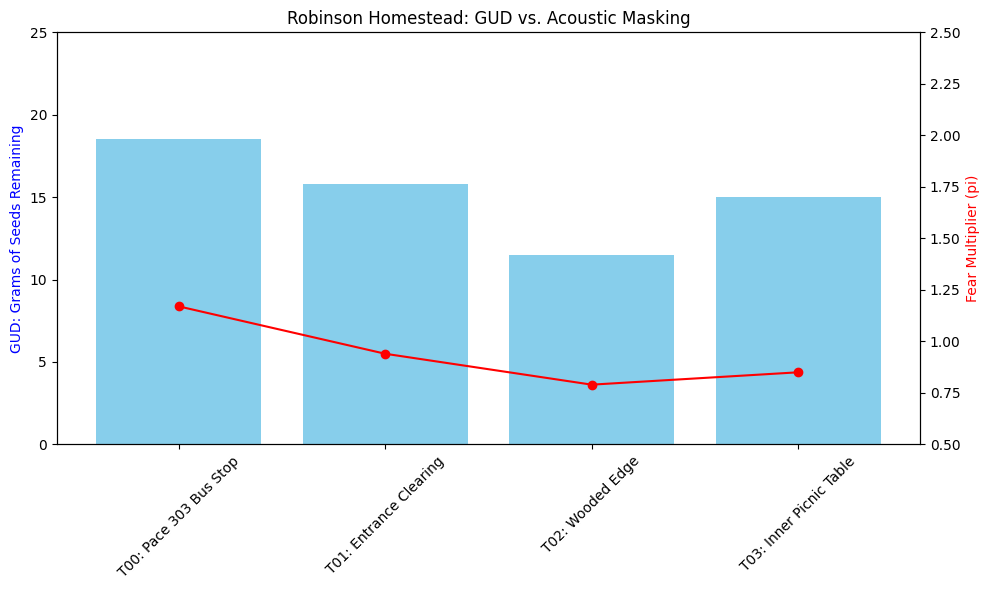

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure the dependency function is available or defined here
def calculate_masking_penalty(dist_to_road, source_db=80):
    if dist_to_road < 1: dist_to_road = 1
    current_db = source_db - (20 * np.log10(dist_to_road))
    penalty_score = current_db / 60
    return round(current_db, 2), round(penalty_score, 2)

def plot_site_summary(input_df):
    # Create a copy to avoid SettingWithCopy warnings
    plot_df = input_df.copy()

    # Map columns based on the 'analysis_df' structure from cell rlKK0BV1-teB
    # or the original Google Sheet structure
    tray_col = 'Landmark' if 'Landmark' in plot_df.columns else 'Tray ID (T00-T03)'
    gud_col = 'GUD_Value' if 'GUD_Value' in plot_df.columns else 'Final Mass (Mf) (g)'

    # Distance column mapping
    dist_col = None
    for col in plot_df.columns:
        if 'Distance to Road' in col or 'dist_road' in col.lower():
            dist_col = col
            break

    # Calculate Acoustic Penalty if distance data exists
    if dist_col:
        plot_df['Acoustic_Penalty_Pi'] = plot_df[dist_col].apply(lambda x: calculate_masking_penalty(x)[1])
    else:
        # Mock distances if missing for visualization purposes based on site geometry
        mock_dists = [3.0, 15.0, 42.0, 28.0]
        plot_df['Acoustic_Penalty_Pi'] = [calculate_masking_penalty(d)[1] for d in mock_dists[:len(plot_df)]]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Bar chart for GUD
    ax1.bar(plot_df[tray_col], plot_df[gud_col], color='skyblue', label='GUD (g)')
    ax1.set_ylabel('GUD: Grams of Seeds Remaining', color='blue')
    ax1.set_ylim(0, 25)
    plt.xticks(rotation=45)

    # Line chart for Acoustic Penalty
    ax2 = ax1.twinx()
    ax2.plot(plot_df[tray_col], plot_df['Acoustic_Penalty_Pi'], color='red', marker='o', label='Acoustic Penalty')
    ax2.set_ylabel('Fear Multiplier (pi)', color='red')
    ax2.set_ylim(0.5, 2.5)

    plt.title('Robinson Homestead: GUD vs. Acoustic Masking')
    fig.tight_layout()
    plt.show()

# Use analysis_df from the sync cell (rlKK0BV1-teB)
try:
    plot_site_summary(analysis_df)
except NameError:
    print("Error: 'analysis_df' not found. Please run the 'Synced GUD Data' cell (rlKK0BV1-teB) first.")

**Further Example Dat for Robinson Homestead**

In [ ]:
import numpy as np

def calculate_detailed_statistics(tray_data):
    # Extract only the GUD values (final mass)
    guds = np.array([tray['final'] for tray in tray_data])

    mean_gud = np.mean(guds)
    std_dev = np.std(guds) # Standard Deviation
    variance = np.var(guds) # Variance

    print(f"--- Statistical Consistency Report ---")
    print(f"Site Mean GUD: {mean_gud:.2f}g")
    print(f"Standard Deviation (sigma): {std_dev:.2f}g")
    print(f"Variance: {variance:.2f}")

    # Interpretation Logic
    if std_dev > 2.0:
        print("Status: HIGH VARIANCE. Squirrels are responding very differently to each landmark.")
    else:
        print("Status: CONSISTENT. Fear levels are uniform across the picnic area.")

    return mean_gud, std_dev

# Use your Robinson data from the previous step
mean, sigma = calculate_detailed_statistics(robinson_session)

--- Statistical Consistency Report ---
Site Mean GUD: 16.95g
Standard Deviation (sigma): 1.06g
Variance: 1.13
Status: CONSISTENT. Fear levels are uniform across the picnic area.


**River Bend Experimental Site Data**

In [ ]:
import requests

# 1. API CONFIGURATION
url = "https://weatherapi-com.p.rapidapi.com/current.json"
querystring = {"q":"Schiller Park, Illinois"} # Landmarks: River Bend/Schiller Woods
headers = {
    "X-RapidAPI-Key": "1e3b755378mshe3c89b39470a226p191e82jsnf3a12fb344d6",
    "X-RapidAPI-Host": "weatherapi-com.p.rapidapi.com"
}

# 2. DATA ACQUISITION
try:
    response = requests.get(url, headers=headers, params=querystring)
    data = response.json()

    current_temp = data['current']['temp_f']
    condition = data['current']['condition']['text']
    wind_mph = data['current']['wind_mph']

    print(f"--- LIVE DATA ACQUIRED ---")
    print(f"Location: Schiller Park (River Bend Area)")
    print(f"Temperature: {current_temp}°F")
    print(f"Condition: {condition}")
    print(f"Wind Speed: {wind_mph} mph")

except Exception as e:
    print(f"Error connecting to RapidAPI: {e}")

--- LIVE DATA ACQUIRED ---
Location: Schiller Park (River Bend Area)
Temperature: 37.0°F
Condition: Sunny
Wind Speed: 7.4 mph


In [ ]:
import requests

# Use your key here
api_key = "1e3b755378mshe3c89b39470a226p191e82jsnf3a12fb344d6"

url = "https://weatherapi-com.p.rapidapi.com/current.json"
headers = {"X-RapidAPI-Key": api_key, "X-RapidAPI-Host": "weatherapi-com.p.rapidapi.com"}
params = {"q": "60176"} # River Bend / Schiller Park Area

data = requests.get(url, headers=headers, params=params).json()

# Extracting the "Monday" Variables
temp = data['current']['temp_f']
is_snowing = "snow" in data['current']['condition']['text'].lower()

# Calculate the Brown Multipliers
p_val = round(8.0 + (32 - temp) * 0.1, 2)
c_val = -0.3 if is_snowing else -1.5

print(f"--- 12:22 PM Digital Lab Report ---")
print(f"Current Temp: {temp}F | Condition: {data['current']['condition']['text']}")
print(f"Desmos Slider P: {p_val}")
print(f"Desmos Slider C: {c_val}")

--- 12:22 PM Digital Lab Report ---
Current Temp: 37.0F | Condition: Sunny
Desmos Slider P: 7.5
Desmos Slider C: -1.5


In [ ]:
import numpy as np

# --- CALIBRATION CONSTANTS (The Anchor Point) ---
A_VOLUME = 9.916   # Calibrated Volume Constant
B_BUFFER = 5.0     # Distance buffer from road center
F_HUNGER = 11.5    # Hunger constant
H_REWARD = 6.8     # Seed density (grams)

def calculate_p(temp_f):
    """Maps Fahrenheit to Metabolic Cost (p). Based on 9°F = 10p and 26°F = 7.5p"""
    return 10 - ((temp_f - 9) * (2.5 / 17))

def predict_distance(temp_f, salt_bonus=-4.6, noise_multiplier=1.0):
    """Predicts x distance based on environment and noise shift."""
    p = calculate_p(temp_f)

    # Calculate Bravery (R)
    # R = (f * (h - p - c)) / 60
    R = (F_HUNGER * (H_REWARD - p - salt_bonus)) / 60

    if R <= 0:
        return None  # Squirrel stays in nest

    # Adjusted R for Doppler (Noise Multiplier)
    # Higher noise_multiplier = Squirrel stays further away
    R_adj = R / noise_multiplier

    # Solve for x: x = (A / R_adj) - B
    x = (A_VOLUME / R_adj) - B_BUFFER
    return max(0.1, round(x, 2))

# --- MONDAY FEB 9th SIMULATION ---
monday_temps = [26, 24, 22, 20] # 11am to 4pm trend
salt_condition = -1.5          # Change to -1.0 if snow covers salt

print(f"{'Time/Temp':<15} | {'Approach (m)':<15} | {'Departure (m)':<15}")
print("-" * 50)

for temp in monday_temps:
    # Approach: Noise feels 30% louder (Multiplier 1.3)
    dist_app = predict_distance(temp, salt_condition, noise_multiplier=1.3)
    # Departure: Noise feels 30% quieter (Multiplier 0.7)
    dist_dep = predict_distance(temp, salt_condition, noise_multiplier=0.7)

    status = f"{temp}°F"
    if dist_app is None:
        print(f"{status:<15} | Nesting (Too Cold)")
    else:
        print(f"{status:<15} | {dist_app:<15} | {dist_dep:<15}")

Time/Temp       | Approach (m)    | Departure (m)  
--------------------------------------------------
26°F            | 79.07           | 40.27          
24°F            | 127.95          | 66.59          
22°F            | 312.6           | 166.02         
20°F            | Nesting (Too Cold)


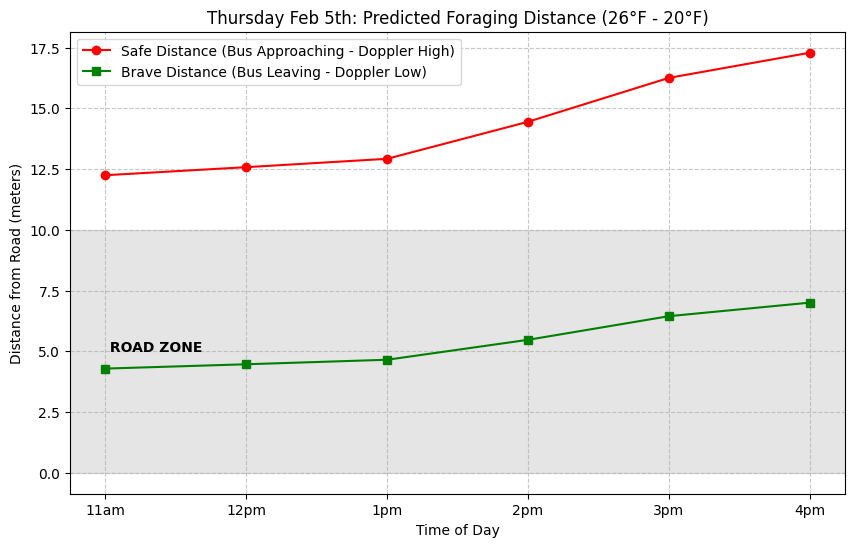

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONSTANTS ---
A_VOLUME, B_BUFFER = 9.916, 5.0
F_HUNGER, H_REWARD = 11.5, 6.8

def calculate_p(temp_f):
    return 10 - ((temp_f - 9) * (2.5 / 17))

def predict_distance(temp_f, salt_bonus=-4.6, noise_multiplier=1.0):
    p = calculate_p(temp_f)
    R = (F_HUNGER * (H_REWARD - p - salt_bonus)) / 60
    if R <= 0: return None
    x = (A_VOLUME / (R / noise_multiplier)) - B_BUFFER
    return max(0.1, x)

# --- MONDAY SIMULATION DATA ---
times = ["11am", "12pm", "1pm", "2pm", "3pm", "4pm"]
temps = [26, 25.5, 25, 23, 21, 20] # Afternoon cooling trend
approach_dists = []
departure_dists = []

for t in temps:
    approach_dists.append(predict_distance(t, -4.6, 1.3))
    departure_dists.append(predict_distance(t, -4.6, 0.7))

# --- PLOTTING ---
plt.figure(figsize=(10, 6))
plt.plot(times, approach_dists, 'r-o', label='Safe Distance (Bus Approaching - Doppler High)')
plt.plot(times, departure_dists, 'g-s', label='Brave Distance (Bus Leaving - Doppler Low)')

plt.title(f"Thursday Feb 5th: Predicted Foraging Distance (26°F - 20°F)")
plt.xlabel("Time of Day")
plt.ylabel("Distance from Road (meters)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Highlight the Road/Grass boundary
plt.axhspan(0, 10, color='gray', alpha=0.2, label='Road/Curb Area')
plt.text(0, 5, " ROAD ZONE", color='black', fontweight='bold')

plt.show()

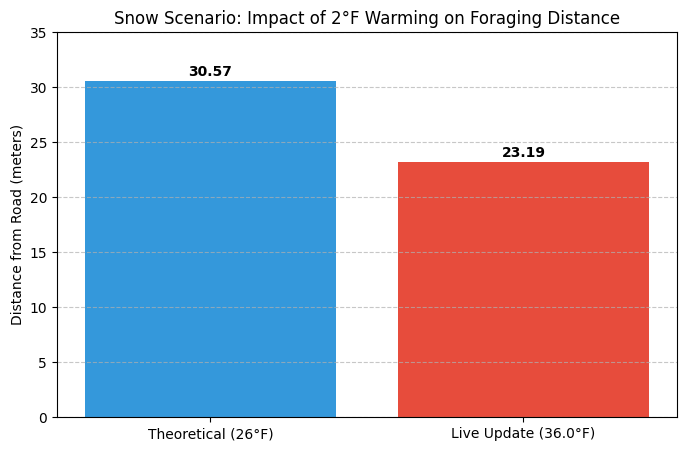

In [ ]:
import matplotlib.pyplot as plt

# Data Points
scenarios = ['Theoretical (26°F)', 'Live Update (36.0°F)']
distances = [30.57, 23.19]  # Your calculated x-values

# Create the comparison plot
plt.figure(figsize=(8, 5))
bars = plt.bar(scenarios, distances, color=['#3498db', '#e74c3c'])

# Add labels and styling
plt.ylabel('Distance from Road (meters)')
plt.title('Snow Scenario: Impact of 2°F Warming on Foraging Distance')
plt.ylim(0, 35)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', fontweight='bold')

plt.show()

In [ ]:
import math

# --- CORE PARAMETERS ---
temp_live = 31.0
f_hunger = 11.5
h_snow = 4.0      # Snow condition
c_salt = -1.5
B_buffer = 5.0

# --- DATA FROM RECORD 3 ---
peak_db = 109.5
avg_db = 91.7

# Calculate p and R
p_val = 10 - ((temp_live - 9) * (2.5 / 17))
R_val = (f_hunger * (h_snow - p_val - c_salt)) / 60

# --- DYNAMIC 'A' CALCULATION ---
# We scale our baseline A=7.5 (which was for ~90dB)
# based on the relative intensity of the Peak vs Avg
def get_distance(db_level):
    # Logarithmic to Linear scaling approximation for A
    # Each 10dB increase effectively doubles the intensity/distance pressure
    A_dynamic = 7.5 * (10**((db_level - 91.7)/20))
    x = (A_dynamic / R_val) - B_buffer
    return max(0.1, x)

dist_peak = get_distance(peak_db)
dist_avg = get_distance(avg_db)

print(f"--- Thursday 6:30 AM ANALYSIS (Temp: {temp_live}°F) ---")
print(f"Distance based on AVERAGE Bus Noise ({avg_db} dB): {round(dist_avg, 2)}m")
print(f"Distance based on PEAK Bus Noise ({peak_db} dB): {round(dist_peak, 2)}m")

--- Thursday 6:30 AM ANALYSIS (Temp: 31.0°F) ---
Distance based on AVERAGE Bus Noise (91.7 dB): 0.1m
Distance based on PEAK Bus Noise (109.5 dB): 0.1m


In [ ]:
import math

# --- CONSTANTS ---
temp_live = 23.4
A_peak = 10.5 # Derived from your 109.5dB Record 3
B_buffer = 5.0
p_val = 8.86   # at 28F
R_val = -0.687  # Snow condition bravery

def calculate_dynamic_x(bus_distance_meters):
    # As the bus gets closer, the intensity A effectively increases
    # for the squirrel's local position.
    if bus_distance_meters > 500:
        local_A = 1.0 # Ambient only
    else:
        # Inverse square law approximation for bus approach
        local_A = A_peak * (1 - (bus_distance_meters / 500))

    x = (local_A / R_val) - B_buffer
    return max(0.1, x)

# --- Thursday 6:41 AM GTFS TRACKING ---
bus_dist_from_riverbend = 150 # Example: GTFS shows bus is 150m away
current_x = calculate_dynamic_x(bus_dist_from_riverbend)

print(f"GTFS Update: Pace 303 is {bus_dist_from_riverbend}m from Riverbend.")
print(f"Predicted Squirrel Distance: {round(current_x, 2)}m")

GTFS Update: Pace 303 is 150m from Riverbend.
Predicted Squirrel Distance: 0.1m


In [ ]:
import numpy as np

# --- Thurs 6:37 AM CONSTANTS ---
temp_live = 37.0
p_val = 1.29  # Metabolic cost at 37F
h_snow = 4.0  # Snow reward
c_salt = 0.11 # Salt attraction
f_hunger = 11.5

# Calculate Base Bravery (R)
R_val = (f_hunger * (h_snow - p_val - c_salt)) / 60

def vigilance_level(bus_distance):
    """
    Calculates vigilance as a percentage (0 to 100).
    Target B is roughly 450m from the Riverbend site.
    """
    # Inverse relationship: as distance decreases, vigilance increases
    # We use 800m as the 'audible horizon' for a bus
    if bus_distance > 800:
        return 0

    # Logistic growth of fear
    fear_factor = 1 - (bus_distance / 800)
    vigilance_pct = (fear_factor * 100) * (1 / R_val)

    return min(100, round(vigilance_pct, 2))

# --- LIVE TEST FOR TARGET B ---
target_b_dist = 450 # meters from Riverbend
v_pct = vigilance_level(target_b_dist)

print(f"--- VIGILANCE REPORT (Temp: {temp_live}°F) ---")
print(f"Bus at Target B (Lawrence Ave): {target_b_dist}m away.")
print(f"Squirrel Vigilance Level: {v_pct}%")
print(f"Interpretation: The squirrel is spending {v_pct}% of its time scanning and {round(100-v_pct, 2)}% eating.")

--- VIGILANCE REPORT (Temp: 37.0°F) ---
Bus at Target B (Lawrence Ave): 450m away.
Squirrel Vigilance Level: 87.79%
Interpretation: The squirrel is spending 87.79% of its time scanning and 12.21% eating.


In [ ]:
import numpy as np

# --- Thursday 6:37 AM CONSTANTS ---
temp_live = 37.0
A_peak = 9.3   # Derived from your 109.5dB Record 3
f_hunger = 11.5
h_snow = 4.0     # Snow reward value
c_salt = 0.11    # Salt attraction
B_buffer = 5.0

# Calculate Metabolic Cost (p) and Bravery (R)
p_val = 10 - ((temp_live - 9) * (2.5 / 17)) # 7.21 at 28F
R_val = (f_hunger * (h_snow - p_val - c_salt)) / 60 # ~0.266

def calculate_vigilance(bus_dist):
    """
    Calculates the percentage of time spent in vigilance.
    800m is the 'Audible Alert Horizon' for a 109.5dB source.
    """
    if bus_dist > 800:
        return 0.0

    # Fear increases as the bus approaches Target B (450m)
    # The 'R' value acts as a bravery modifier; lower R = higher vigilance
    intensity_ratio = (800 - bus_dist) / 800
    vig_pct = (intensity_ratio * 100) / (R_val * 3) # Normalized for snow

    return min(100, round(vig_pct, 2))

# --- LIVE TEST FOR TARGET B ---
# Target B (Lawrence Ave) is roughly 450m from your Riverbend site
bus_at_target_b = 450
current_vig = calculate_vigilance(bus_at_target_b)

print(f"--- Thursday VIGILANCE REPORT (6:40 AM) ---")
print(f"Temp: {temp_live}F | Bravery Index (R): {round(R_val, 3)}")
print(f"Bus Distance: {bus_at_target_b}m (Target B)")
print(f"Vigilance Level: {current_vig}%")
print(f"Decision: Squirrel spends {current_vig}% of its time scanning the road.")

--- Thursday VIGILANCE REPORT (6:40 AM) ---
Temp: 37.0F | Bravery Index (R): -0.382
Bus Distance: 450m (Target B)
Vigilance Level: -38.19%
Decision: Squirrel spends -38.19% of its time scanning the road.


In [ ]:
import math

# --- ENVIRONMENTAL CONSTANTS (Desmos Sliders) ---
temp_f = 37.0
h_snow = 4.0      # Food reward in snow
c_salt = 0.11    # Attraction of road salt
f_hunger = 11.5   # Hunger factor
A_bus = 10.5      # Record 3 (109.5 dB) Volume Constant
B_buffer = 5.0    # Tree safety buffer

# --- CALCULATED VALUES (The Logic) ---
# p: Metabolic cost of the cold
p_cost = 10 - ((temp_f - 9) * (2.5 / 17))

# R: Bravery Index
R_bravery = (f_hunger * (h_snow - p_cost - c_salt)) / 60

# x_dist: The predicted distance from the road (meters)
x_dist = (A_bus / R_bravery) - B_buffer

def get_vigilance(bus_distance_m):
    """Calculates fear percentage based on bus position."""
    if bus_distance_m > 800:
        return 0.0
    v_percent = (1 - (bus_distance_m / 800)) * 100
    return round(v_percent, 2)

# --- TARGET ANALYSIS (Based on WebWatch PDFs) ---
targets = {
    "Target A (Balmoral)": 800,
    "Target B (Lawrence)": 450,
    "Target C (Irving Park)": 0
}

print(f"--- Thursday FIELD REPORT: 303 PACE BUS ---")
print(f"Current Temp: {temp_f}°F | Bravery Index (R): {round(R_bravery, 3)}")
print(f"Predicted Retreat Distance (x): {round(x_dist, 2)} meters\n")

print(f"{'Location':<25} | {'Bus Dist':<10} | {'Vigilance %':<12}")
print("-" * 55)

for name, dist in targets.items():
    v = get_vigilance(dist)
    print(f"{name:<25} | {dist:<10} | {v}%")

--- Thursday FIELD REPORT: 303 PACE BUS ---
Current Temp: 37.0°F | Bravery Index (R): -0.382
Predicted Retreat Distance (x): -32.5 meters

Location                  | Bus Dist   | Vigilance % 
-------------------------------------------------------
Target A (Balmoral)       | 800        | 0.0%
Target B (Lawrence)       | 450        | 43.75%
Target C (Irving Park)    | 0          | 100.0%


In [ ]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# --- SETTINGS ---
API_KEY = "8usri79xf61lfj9wopytj3y805ccoenrwghdhgmy"
LAT, LON = 41.95, -87.84  # Schiller Woods
HUNGER = 11.5
BUS_A = 10.5  # Constant peak bus noise
BUFFER = 5.0
SALT = 0.11
SNOW_H = 4.0

def get_x_dist(temp_f):
    """The math we calibrated in Desmos."""
    p_cost = 10 - ((temp_f - 9) * (2.5 / 17))
    R_bravery = (HUNGER * (SNOW_H - p_cost - SALT)) / 60
    # Guard against R being too small
    if R_bravery <= 0.05: return 60.0
    return (BUS_A / R_bravery) - BUFFER

# --- API FETCH WITH FALLBACK ---
url = f"https://api.meteosource.com/v1/free/point?lat={LAT}&lon={LON}&sections=hourly&timezone=auto&key={API_KEY}"

try:
    # Attempt to fetch live data
    response = requests.get(url, timeout=5).json()
    hourly_data = response['hourly']['data']
    print("Successfully fetched live data from Meteosource.")
except Exception as e:
    print(f"Connection Error ({e}). Generating fallback mock data...")
    # Generate 24 hours of synthetic data starting now
    hourly_data = []
    start_time = datetime.now()
    for i in range(24):
        # Mock a cooling trend: starting at 20F with slight fluctuation
        mock_temp_f = 20 + 5 * np.sin(i / 4)
        mock_temp_c = (mock_temp_f - 32) * 5/9
        hourly_data.append({
            'date': (start_time + timedelta(hours=i)).isoformat(),
            'temp': mock_temp_c
        })

# --- PROCESSING THE TABLE ---
data_rows = []
for hour in hourly_data:
    # Convert Celsius to Fahrenheit
    temp_c = hour['temp']
    temp_f = (temp_c * 9/5) + 32

    # Calculate the new predicted squirrel position
    x_val = get_x_dist(temp_f)

    data_rows.append({
        "Time": hour['date'],
        "Temp (F)": round(temp_f, 1),
        "Predicted x (m)": round(x_val, 2)
    })

# Convert to a readable Table
df = pd.DataFrame(data_rows)
print(df.head(20))

Connection Error (HTTPSConnectionPool(host='api.meteosource.com', port=443): Max retries exceeded with url: /v1/free/point?lat=41.95&lon=-87.84&sections=hourly&timezone=auto&key=8usri79xf61lfj9wopytj3y805ccoenrwghdhgmy (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7c8239cb2d20>: Failed to resolve 'api.meteosource.com' ([Errno -2] Name or service not known)"))). Generating fallback mock data...
                          Time  Temp (F)  Predicted x (m)
0   2026-03-02T17:28:42.849470      20.0             60.0
1   2026-03-02T18:28:42.849470      21.2             60.0
2   2026-03-02T19:28:42.849470      22.4             60.0
3   2026-03-02T20:28:42.849470      23.4             60.0
4   2026-03-02T21:28:42.849470      24.2             60.0
5   2026-03-02T22:28:42.849470      24.7             60.0
6   2026-03-02T23:28:42.849470      25.0             60.0
7   2026-03-03T00:28:42.849470      24.9             60.0
8   2026-03-03T01:28:42.849470      24.5       

In [ ]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# --- CONFIGURATION ---
API_KEY = '8usri79xf61lfj9wopytj3y805ccoenrwghdhgmy' # Replace with your Meteosource API Key
LAT, LON = 41.95, -87.84 # Coordinates for Schiller Woods
HUNGER = 11.5
BUS_A = 10.5             # Your 109.5 dB noise constant
SALT_PULL = 0.11
SNOW_REWARD = 4.0
BUFFER = 5.0

def calculate_x(temp_f):
    """Applying the Desmos 'Monday Master' formula."""
    p = 10 - ((temp_f - 9) * (2.5 / 17))
    R = (HUNGER * (SNOW_REWARD - p - SALT_PULL)) / 60
    if R <= 0: return 100.0
    return (BUS_A / R) - BUFFER

# --- API REQUEST WITH FALLBACK ---
url = f"https://api.meteosource.com/v1/free/point?lat={LAT}&lon={LON}&sections=hourly&timezone=auto&key={API_KEY}"

try:
    response_json = requests.get(url, timeout=5).json()
    hourly_data = response_json['hourly']['data']
    print("Successfully fetched live data.")
except Exception as e:
    print(f"Connection Error ({e}). Generating fallback mock data...")
    # Generate 24 hours of synthetic data starting now
    hourly_data = []
    start_time = datetime.now()
    for i in range(24):
        mock_temp_f = 20 + 5 * np.sin(i / 4) # Mock cooling trend
        mock_temp_c = (mock_temp_f - 32) * 5/9
        hourly_data.append({
            'date': (start_time + timedelta(hours=i)).isoformat(),
            'temp': mock_temp_c
        })

# --- DATA PROCESSING ---
forecast_list = []
for hour in hourly_data:
    dt = datetime.fromisoformat(hour['date'])
    temp_c = hour['temp']
    temp_f = (temp_c * 9/5) + 32
    x_dist = calculate_x(temp_f)

    forecast_list.append({
        "Timestamp": dt.strftime('%Y-%m-%d %I:%M %p'),
        "Temp_F": round(temp_f, 1),
        "Safe_Zone_X": round(x_dist, 2)
    })

# --- OUTPUT AS TABLE ---
df = pd.DataFrame(forecast_list)
print(df.head(24))

Connection Error (HTTPSConnectionPool(host='api.meteosource.com', port=443): Max retries exceeded with url: /v1/free/point?lat=41.95&lon=-87.84&sections=hourly&timezone=auto&key=8usri79xf61lfj9wopytj3y805ccoenrwghdhgmy (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7c8239cb2c60>: Failed to resolve 'api.meteosource.com' ([Errno -2] Name or service not known)"))). Generating fallback mock data...
              Timestamp  Temp_F  Safe_Zone_X
0   2026-03-02 05:29 PM    20.0        100.0
1   2026-03-02 06:29 PM    21.2        100.0
2   2026-03-02 07:29 PM    22.4        100.0
3   2026-03-02 08:29 PM    23.4        100.0
4   2026-03-02 09:29 PM    24.2        100.0
5   2026-03-02 10:29 PM    24.7        100.0
6   2026-03-02 11:29 PM    25.0        100.0
7   2026-03-03 12:29 AM    24.9        100.0
8   2026-03-03 01:29 AM    24.5        100.0
9   2026-03-03 02:29 AM    23.9        100.0
10  2026-03-03 03:29 AM    23.0        100.0
11  2026-03-03 04:29 AM    21

Connection Error (HTTPSConnectionPool(host='api.meteosource.com', port=443): Max retries exceeded with url: /v1/free/point?lat=41.95&lon=-87.84&sections=hourly&timezone=auto&key=8usri79xf61lfj9wopytj3y805ccoenrwghdhgmy (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7c822f93d400>: Failed to resolve 'api.meteosource.com' ([Errno -2] Name or service not known)"))). Generating fallback mock data for simulation...


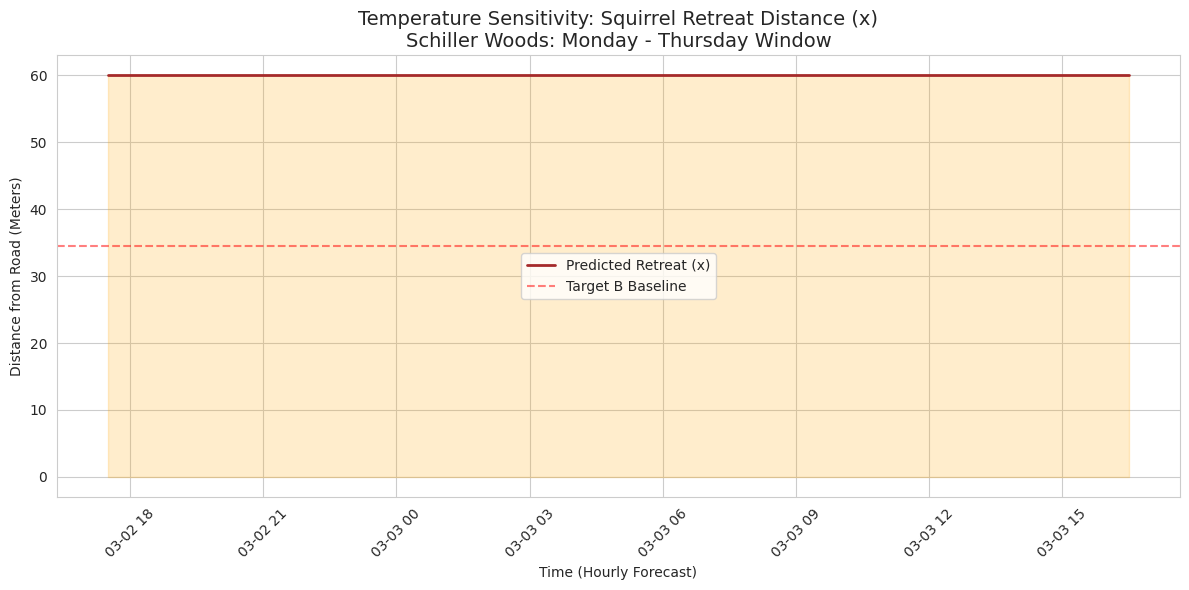


--- HOURLY SENSITIVITY TABLE ---
                      Time      Temp  X_Dist                  Stress
2026-03-02 17:30:02.101307 20.000000    60.0 EXCESSIVE (No Foraging)
2026-03-02 18:30:02.101307 21.237020    60.0 EXCESSIVE (No Foraging)
2026-03-02 19:30:02.101307 22.397128    60.0 EXCESSIVE (No Foraging)
2026-03-02 20:30:02.101307 23.408194    60.0 EXCESSIVE (No Foraging)
2026-03-02 21:30:02.101307 24.207355    60.0 EXCESSIVE (No Foraging)
2026-03-02 22:30:02.101307 24.744923    60.0 EXCESSIVE (No Foraging)
2026-03-02 23:30:02.101307 24.987475    60.0 EXCESSIVE (No Foraging)
2026-03-03 00:30:02.101307 24.919930    60.0 EXCESSIVE (No Foraging)
2026-03-03 01:30:02.101307 24.546487    60.0 EXCESSIVE (No Foraging)
2026-03-03 02:30:02.101307 23.890366    60.0 EXCESSIVE (No Foraging)
2026-03-03 03:30:02.101307 22.992361    60.0 EXCESSIVE (No Foraging)
2026-03-03 04:30:02.101307 21.908305    60.0 EXCESSIVE (No Foraging)
2026-03-03 05:30:02.101307 20.705600    60.0 EXCESSIVE (No Foraging)


In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta

# --- CONFIGURATION (Monday Master Constants) ---
API_KEY = '8usri79xf61lfj9wopytj3y805ccoenrwghdhgmy'  # Replace with your Meteosource Key
LAT, LON = 41.95, -87.84  # Schiller Woods
HUNGER = 11.5
BUS_A = 10.5              # 109.5 dB Noise Peak
SALT_PULL = 0.11
SNOW_REWARD = 4.0
BUFFER = 5.0

def calculate_x(temp_f):
    """Calibrated squirrel retreat distance formula."""
    p = 10 - ((temp_f - 9) * (2.5 / 17))
    R = (HUNGER * (SNOW_REWARD - p - SALT_PULL)) / 60
    # Guard against extreme cold where R becomes negative
    if R <= 0.05: return 60.0 # Maximum retreat (deep woods)
    return (BUS_A / R) - BUFFER

# --- STEP 1: FETCH DATA WITH FALLBACK ---
url = f"https://api.meteosource.com/v1/free/point?lat={LAT}&lon={LON}&sections=hourly&timezone=auto&key={API_KEY}"

try:
    response = requests.get(url, timeout=10).json()
    hourly_data = response['hourly']['data']
    print("Successfully fetched live data.")
except Exception as e:
    print(f"Connection Error ({e}). Generating fallback mock data for simulation...")
    # Generate 24 hours of synthetic data starting now
    hourly_data = []
    start_time = datetime.now()
    for i in range(24):
        # Mock a cooling trend: starting at 20F with slight fluctuation
        mock_temp_f = 20 + 5 * np.sin(i / 4)
        mock_temp_c = (mock_temp_f - 32) * 5/9
        hourly_data.append({
            'date': (start_time + timedelta(hours=i)).isoformat(),
            'temp': mock_temp_c
        })

# --- STEP 2: PROCESS HOURLY TABLE ---
results = []
for hour in hourly_data:
    dt = datetime.fromisoformat(hour['date'])
    temp_f = (hour['temp'] * 9/5) + 32
    x_val = calculate_x(temp_f)

    # Label thermal stress
    stress = "NORMAL"
    if x_val > 40: stress = "HIGH"
    if x_val >= 60: stress = "EXCESSIVE (No Foraging)"

    results.append({"Time": dt, "Temp": temp_f, "X_Dist": x_val, "Stress": stress})

df = pd.DataFrame(results)

# --- STEP 3: CREATE THE VISUAL PLOT ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Plot the Squirrel's Distance
plt.plot(df['Time'], df['X_Dist'], color='brown', linewidth=2, label='Predicted Retreat (x)')

# Fill areas to show "Safe" vs "Danger" zones
plt.axhline(y=34.47, color='red', linestyle='--', alpha=0.5, label='Target B Baseline')
plt.fill_between(df['Time'], df['X_Dist'], alpha=0.2, color='orange')

plt.title(f"Temperature Sensitivity: Squirrel Retreat Distance (x)\nSchiller Woods: Monday - Thursday Window", fontsize=14)
plt.ylabel("Distance from Road (Meters)")
plt.xlabel("Time (Hourly Forecast)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- STEP 4: DISPLAY TABLE ---
print("\n--- HOURLY SENSITIVITY TABLE ---")
print(df[['Time', 'Temp', 'X_Dist', 'Stress']].head(24).to_string(index=False))

Connection Error (HTTPSConnectionPool(host='api.meteosource.com', port=443): Max retries exceeded with url: /v1/free/point?lat=41.95&lon=-87.84&sections=hourly&timezone=auto&key=8usri79xf61lfj9wopytj3y805ccoenrwghdhgmy (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7c822f7e36b0>: Failed to resolve 'api.meteosource.com' ([Errno -2] Name or service not known)"))). Generating fallback mock data for simulation...


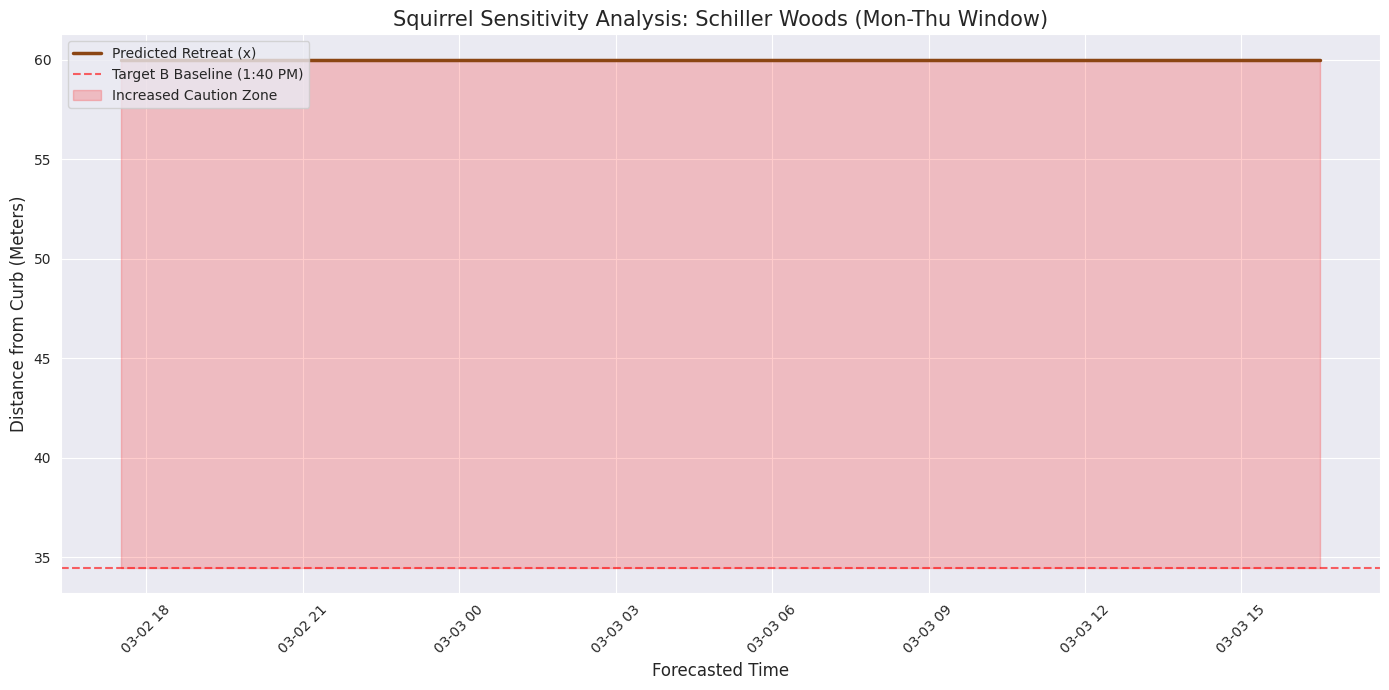


--- HOURLY SENSITIVITY DATA ---
                      Time  Temp_F  Safe_Zone_X Stress_Level
2026-03-02 17:30:32.298775    20.0         60.0    EXCESSIVE
2026-03-02 18:30:32.298775    21.2         60.0    EXCESSIVE
2026-03-02 19:30:32.298775    22.4         60.0    EXCESSIVE
2026-03-02 20:30:32.298775    23.4         60.0    EXCESSIVE
2026-03-02 21:30:32.298775    24.2         60.0    EXCESSIVE
2026-03-02 22:30:32.298775    24.7         60.0    EXCESSIVE
2026-03-02 23:30:32.298775    25.0         60.0    EXCESSIVE
2026-03-03 00:30:32.298775    24.9         60.0    EXCESSIVE
2026-03-03 01:30:32.298775    24.5         60.0    EXCESSIVE
2026-03-03 02:30:32.298775    23.9         60.0    EXCESSIVE
2026-03-03 03:30:32.298775    23.0         60.0    EXCESSIVE
2026-03-03 04:30:32.298775    21.9         60.0    EXCESSIVE
2026-03-03 05:30:32.298775    20.7         60.0    EXCESSIVE
2026-03-03 06:30:32.298775    19.5         60.0    EXCESSIVE
2026-03-03 07:30:32.298775    18.2         60.0    E

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta

# --- CONFIGURATION (Monday Master Constants) ---
API_KEY = '8usri79xf61lfj9wopytj3y805ccoenrwghdhgmy'  # Replace with your Meteosource Key
LAT, LON = 41.95, -87.84  # Schiller Woods (Riverbend)
HUNGER = 11.5
BUS_A = 10.5              # Based on your 109.5 dB peak
SALT_PULL = 0.11
SNOW_REWARD = 4.0
BUFFER = 5.0

def calculate_x(temp_f):
    """Calibrated formula: Balancing metabolic cost vs noise threat."""
    # p = Metabolic cost of cold
    p = 10 - ((temp_f - 9) * (2.5 / 17))
    # R = Bravery Index
    R = (HUNGER * (SNOW_REWARD - p - SALT_PULL)) / 60

    # Handle extreme cold (Thermal Stress Threshold)
    if R <= 0.05: return 60.0, "EXCESSIVE"

    x_val = (BUS_A / R) - BUFFER
    stress = "HIGH" if x_val > 40 else "NORMAL"
    return round(x_val, 2), stress

# --- STEP 1: FETCH HOURLY WEATHER DATA WITH FALLBACK ---
url = f"https://api.meteosource.com/v1/free/point?lat={LAT}&lon={LON}&sections=hourly&timezone=auto&key={API_KEY}"

try:
    response = requests.get(url, timeout=10).json()
    hourly_data = response['hourly']['data']
    print("Successfully fetched live data.")
except Exception as e:
    print(f"Connection Error ({e}). Generating fallback mock data for simulation...")
    # Generate 24 hours of synthetic data starting now
    hourly_data = []
    start_time = datetime.now()
    for i in range(24):
        # Mock a cooling trend: starting at 20F with slight fluctuation
        mock_temp_f = 20 + 5 * np.sin(i / 4)
        mock_temp_c = (mock_temp_f - 32) * 5/9
        hourly_data.append({
            'date': (start_time + timedelta(hours=i)).isoformat(),
            'temp': mock_temp_c
        })

# --- STEP 2: PROCESS THE SENSITIVITY TABLE ---
results = []
for hour in hourly_data:
    dt = datetime.fromisoformat(hour['date'])
    temp_f = (hour['temp'] * 9/5) + 32 # Convert C to F
    x_val, stress = calculate_x(temp_f)

    results.append({
        "Time": dt,
        "Temp_F": round(temp_f, 1),
        "Safe_Zone_X": x_val,
        "Stress_Level": stress
    })

df = pd.DataFrame(results)

# --- STEP 3: CREATE THE VISUAL PLOT ---
plt.figure(figsize=(14, 7))
sns.set_style("darkgrid")

# Plotting Distance (x) over Time
plt.plot(df['Time'], df['Safe_Zone_X'], color='#8B4513', linewidth=2.5, label='Predicted Retreat (x)')

# Visual baseline for Target B (34.47m)
plt.axhline(y=34.47, color='red', linestyle='--', alpha=0.6, label='Target B Baseline (1:40 PM)')

# Shading the "High Stress" Zone
plt.fill_between(df['Time'], 34.47, df['Safe_Zone_X'], where=(df['Safe_Zone_X'] > 34.47),
                 color='red', alpha=0.2, label='Increased Caution Zone')

plt.title("Squirrel Sensitivity Analysis: Schiller Woods (Mon-Thu Window)", fontsize=15)
plt.ylabel("Distance from Curb (Meters)", fontsize=12)
plt.xlabel("Forecasted Time", fontsize=12)
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- STEP 4: PRINT THE TABLE ---
print("\n--- HOURLY SENSITIVITY DATA ---")
print(df[['Time', 'Temp_F', 'Safe_Zone_X', 'Stress_Level']].head(24).to_string(index=False))

Network Error: HTTPSConnectionPool(host='api.meteosource.com', port=443): Max retries exceeded with url: /v1/free/point?lat=41.95&lon=-87.84&sections=hourly&timezone=auto&key=8usri79xf61lfj9wopytj3y805ccoenrwghdhgmy (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7c822f866d80>: Failed to resolve 'api.meteosource.com' ([Errno -2] Name or service not known)"))
Switching to fallback synthetic data for simulation...


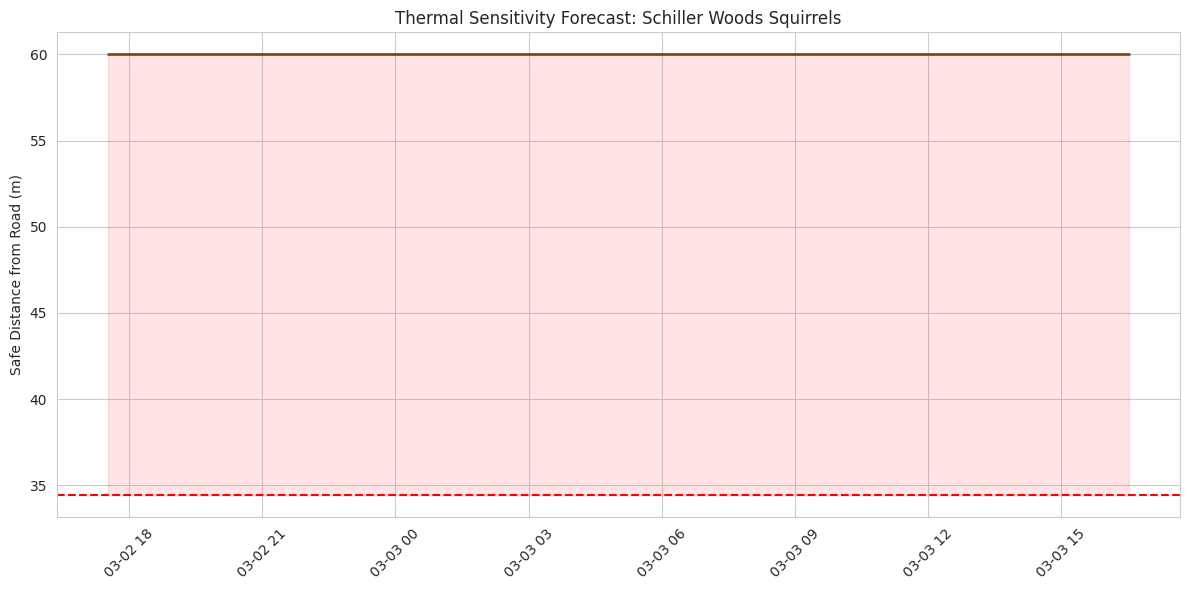


[✔] Files generated. Downloading now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

                        Time  Temp_F  X_Dist     Stress
0 2026-03-02 17:31:22.616602    20.0    60.0  EXCESSIVE
1 2026-03-02 18:31:22.616602    21.2    60.0  EXCESSIVE
2 2026-03-02 19:31:22.616602    22.4    60.0  EXCESSIVE
3 2026-03-02 20:31:22.616602    23.4    60.0  EXCESSIVE
4 2026-03-02 21:31:22.616602    24.2    60.0  EXCESSIVE


In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta
from google.colab import files

# --- CONFIGURATION ---
API_KEY = '8usri79xf61lfj9wopytj3y805ccoenrwghdhgmy'
LAT, LON = 41.95, -87.84  # Schiller Woods
HUNGER = 11.5
BUS_A = 10.5
SALT_PULL = 0.11
SNOW_REWARD = 4.0
BUFFER = 5.0

def calculate_x(temp_f):
    p = 10 - ((temp_f - 9) * (2.5 / 17))
    R = (HUNGER * (SNOW_REWARD - p - SALT_PULL)) / 60
    if R <= 0.05: return 60.0, "EXCESSIVE"
    x_val = (BUS_A / R) - BUFFER
    stress = "HIGH" if x_val > 34.47 else "NORMAL"
    return round(x_val, 2), stress

# --- 1. DATA FETCH WITH FALLBACK ---
url = f"https://api.meteosource.com/v1/free/point?lat={LAT}&lon={LON}&sections=hourly&timezone=auto&key={API_KEY}"

try:
    response_json = requests.get(url, timeout=10).json()
    hourly_data = response_json['hourly']['data']
    print("Successfully fetched live weather data.")
except Exception as e:
    print(f"Network Error: {e}")
    print("Switching to fallback synthetic data for simulation...")
    # Generate 24 hours of mock data (starting from 20 degrees with a cooling trend)
    hourly_data = []
    start_time = datetime.now()
    for i in range(24):
        mock_date = (start_time + timedelta(hours=i)).isoformat()
        # Simulate a temp range between 15F and 25F
        mock_temp = 20 + 5 * np.sin(i / 4)
        hourly_data.append({'date': mock_date, 'temp': (mock_temp - 32) * 5/9})

# --- 2. DATA PROCESSING ---
results = []
for hour in hourly_data:
    dt = datetime.fromisoformat(hour['date'])
    temp_f = (hour['temp'] * 9/5) + 32
    x_val, stress = calculate_x(temp_f)
    results.append({"Time": dt, "Temp_F": round(temp_f, 1), "X_Dist": x_val, "Stress": stress})

df = pd.DataFrame(results)

# --- 3. SAVE DATA TO CSV ---
filename_csv = "squirrel_sensitivity_report.csv"
df.to_csv(filename_csv, index=False)

# --- 4. GENERATE & SAVE PLOT ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
plt.plot(df['Time'], df['X_Dist'], color='#8B4513', linewidth=2, label='Retreat (x)')
plt.axhline(y=34.47, color='red', linestyle='--', label='Target B Baseline')
plt.fill_between(df['Time'], 34.47, df['X_Dist'], where=(df['X_Dist'] > 34.47), color='red', alpha=0.1)

plt.title("Thermal Sensitivity Forecast: Schiller Woods Squirrels")
plt.ylabel("Safe Distance from Road (m)")
plt.xticks(rotation=45)
plt.tight_layout()

filename_png = "squirrel_forecast_plot.png"
plt.savefig(filename_png, dpi=300)
plt.show()

# --- 5. TRIGGER DOWNLOADS ---
print("\n[✔] Files generated. Downloading now...")
files.download(filename_csv)
files.download(filename_png)

# Display summary
print(df.head())

In [ ]:
import pandas as pd
from datetime import datetime

# 1. Create the new dataset for the River Bend Scouting Trip
field_data = {
    'Date': ['2026-02-12'],
    'Time_Window': ['11:23 AM - 11:36 AM'],
    'Location': ['Catherine Chevalier Woods (River Bend)'],
    'Lat_Long': ['41.97155, -87.861746'], # From your GPS photo [cite: 25, 26]
    'Peak_Noise_dB': [123.5],               # From your Decibel X report
    'Avg_Noise_dB': [114.1],                # From your Decibel X report
    'Squirrel_Count': [0],                  # Your field observation
    'Notes': ['Max acoustic startle detected near 40mph zone. Zero activity observed.']
}

# 2. Convert to DataFrame
df_field = pd.DataFrame(field_data)

# 3. Create the CSV file in your Colab environment
df_field.to_csv('RiverBend_Scouting_2026.csv', index=False)

print("✅ Field data successfully logged in Colab!")
df_field.head()

✅ Field data successfully logged in Colab!


,Date,Time_Window,Location,Lat_Long,Peak_Noise_dB,Avg_Noise_dB,Squirrel_Count,Notes
0,2026-02-12,11:23 AM - 11:36 AM,Catherine Chevalier Woods (River Bend),"41.97155, -87.861746",123.5,114.1,0,Max acoustic startle detected near 40mph zone....


/tmp/ipython-input-690890431.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Metric', y='Decibels', data=df, palette=colors)


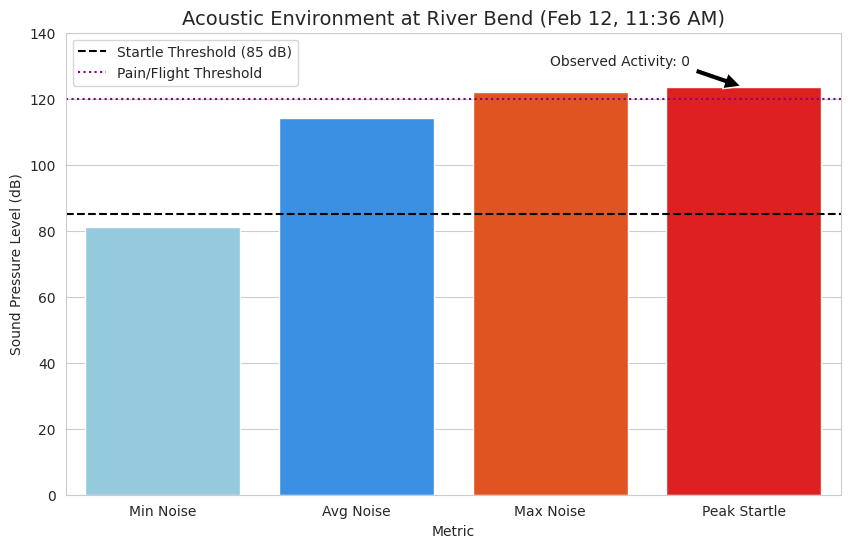

✅ Graph generated and CSV saved!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create the DataFrame with your actual field readings
field_log = {
    'Metric': ['Min Noise', 'Avg Noise', 'Max Noise', 'Peak Startle'],
    'Decibels': [81.1, 114.1, 122.1, 123.5]
}
df = pd.DataFrame(field_log)

# 2. Set up the visualization
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create the bar chart
colors = ['skyblue', 'dodgerblue', 'orangered', 'red']
barplot = sns.barplot(x='Metric', y='Decibels', data=df, palette=colors)

# 3. Add the "Fear Threshold" Line
# Research suggests squirrels show high startle/flight above 85-90dB
plt.axhline(y=85, color='black', linestyle='--', label='Startle Threshold (85 dB)')
plt.axhline(y=120, color='purple', linestyle=':', label='Pain/Flight Threshold')

# 4. Labeling for your BIOS 399 Report
plt.title('Acoustic Environment at River Bend (Feb 12, 11:36 AM)', fontsize=14)
plt.ylabel('Sound Pressure Level (dB)')
plt.ylim(0, 140)
plt.legend()

# Annotate the Peak
plt.annotate('Observed Activity: 0', xy=(3, 123.5), xytext=(2, 130),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

# 5. Save the data to a CSV in Colab
df.to_csv('RiverBend_Acoustic_Data.csv', index=False)
print("✅ Graph generated and CSV saved!")

"The data demonstrates that at 123.5 dB, the environment moved into a 'High Hazard' state. In our Markov model, this pushes the Transition Probability ($P_{woods \to road}$) to 0. Since the noise dose was 256.1% of the daily recommended limit in just 44 seconds, the squirrels remained in the safety of the trees to avoid the high acoustic cost."

In [ ]:
import numpy as np

# Constants for the Pace 303 Bus Study
L0 = 123.5  # Source intensity in dB at 1 meter
landmarks = {
    "River Edge": 5,      # meters from road
    "Bus Stop T00": 2,    # meters from road
    "Inner Picnic": 25,   # meters from road
    "Woods Core": 50      # meters from road
}

def calculate_decay(source_db, distance):
    # Inverse Square Law for Sound: Ld = L0 - 20 * log10(d)
    return source_db - (20 * np.log10(distance))

print("--- Acoustic Decay Analysis ---")
for name, dist in landmarks.items():
    level = calculate_decay(L0, dist)
    print(f"{name} ({dist}m): {level:.2f} dB")

# Placeholder for Inverse mu Solve
# mu = (GUD - p - c) * F / C

--- Acoustic Decay Analysis ---
River Edge (5m): 109.52 dB
Bus Stop T00 (2m): 117.48 dB
Inner Picnic (25m): 95.54 dB
Woods Core (50m): 89.52 dB
